In [1]:
# ── Environment — must come before torch import to suppress CUDA warnings ──
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["TORCH_CPP_LOG_LEVEL"]  = "ERROR"

# ── Imports ────────────────────────────────────────────────────────────────
import random
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Configuration ──────────────────────────────────────────────────────────
DATASET_ROOT    = "../DATA/tree"
IMAGE_SIZE      = (128, 128)
BATCH_SIZE      = 128
NUM_EPOCHS      = 10
NUM_WORKERS     = 2
RANDOM_SEED     = 42
SAVE_DIR        = "../OUTPUT/processed"
LEARNING_RATE   = 3e-4
WEIGHT_DECAY    = 1e-4
LABEL_SMOOTHING = 0.1
FREEZE_FRACTION = 0.9

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

BEST_MODEL_PATH  = os.path.join(SAVE_DIR, "best_model.pth")
FINAL_MODEL_PATH = os.path.join(SAVE_DIR, "final_model.pth")

# ── Transforms ─────────────────────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[0] + 16, IMAGE_SIZE[1] + 16)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

inference_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


# ── Dataset helpers ────────────────────────────────────────────────────────
class CleanImageFolder(datasets.ImageFolder):
    """
    ImageFolder subclass that overrides find_classes() to skip hidden/system
    directories like .ipynb_checkpoints and .DS_Store.

    Why this works when is_valid_file() does not
    ---------------------------------------------
    ImageFolder calls find_classes() FIRST to build its list of valid classes.
    If .ipynb_checkpoints appears in that list, ImageFolder then scans it for
    images and raises FileNotFoundError when it finds none — before
    is_valid_file() ever gets a chance to run.

    By overriding find_classes() to filter out any folder whose name starts
    with '.', we stop the hidden folder from being registered as a class
    at all, so the error never occurs.
    """

    def find_classes(self, directory):
        classes = sorted([
            d.name for d in Path(directory).iterdir()
            if d.is_dir() and not d.name.startswith(".")
        ])
        if not classes:
            raise FileNotFoundError(
                f"No valid class folders found in '{directory}'.\n"
                "Make sure each split folder contains one subfolder per tree species."
            )
        class_to_idx = {cls: i for i, cls in enumerate(classes)}
        return classes, class_to_idx


def build_dataloaders(dataset_root, batch_size=BATCH_SIZE,
                      num_workers=NUM_WORKERS):
    """
    Load train/, val/, and test/ splits using CleanImageFolder, which
    automatically ignores hidden system folders like .ipynb_checkpoints.

    Returns
    -------
    train_loader, val_loader, test_loader : DataLoader
    class_names                           : list[str]
    """
    train_root = os.path.join(dataset_root, "train")
    val_root   = os.path.join(dataset_root, "val")
    test_root  = os.path.join(dataset_root, "test")

    for split_path in (train_root, val_root, test_root):
        if not Path(split_path).exists():
            raise FileNotFoundError(
                f"Expected split folder not found: '{split_path}'\n"
                "Make sure DATASET_ROOT contains train/, val/, and test/ subfolders."
            )

    train_ds = CleanImageFolder(train_root, transform=train_transforms)
    val_ds   = CleanImageFolder(val_root,   transform=test_transforms)
    test_ds  = CleanImageFolder(test_root,  transform=test_transforms)

    class_names = train_ds.classes
    print(f"  Detected {len(class_names)} classes: {class_names}")

    # Warn if val/ or test/ are missing any class that train/ has
    if val_ds.classes != class_names or test_ds.classes != class_names:
        print("  WARNING: class lists differ between splits!")
        print(f"    train : {class_names}")
        print(f"    val   : {val_ds.classes}")
        print(f"    test  : {test_ds.classes}")

    persistent = num_workers > 0
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=False,
                              persistent_workers=persistent)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=False,
                              persistent_workers=persistent)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=False,
                              persistent_workers=persistent)

    return train_loader, val_loader, test_loader, class_names


def visualise_batch(loader, class_names, n=16, save_path=None):
    images, labels = next(iter(loader))
    images, labels = images[:n], labels[:n]
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    show = (images * std + mean).clamp(0, 1)
    grid = make_grid(show, nrow=4, padding=4)
    plt.figure(figsize=(12, 8))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    names = [class_names[l] for l in labels.tolist()]
    plt.title("  |  ".join(names[:4]) + "\n" + "  |  ".join(names[4:8]))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"  Sample grid saved    -> '{save_path}'")
    else:
        plt.show()
    plt.close()


# ── Model ──────────────────────────────────────────────────────────────────
def build_efficientnetv2(num_classes: int,
                          freeze_fraction: float = FREEZE_FRACTION,
                          dropout: float = 0.3) -> nn.Module:
    weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
    model   = models.efficientnet_v2_s(weights=weights)

    backbone_layers = list(model.features.children())
    freeze_up_to    = int(len(backbone_layers) * freeze_fraction)
    for i, layer in enumerate(backbone_layers):
        for param in layer.parameters():
            param.requires_grad = i >= freeze_up_to

    in_features = model.classifier[1].in_features   # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, 256),
        nn.SiLU(),
        nn.Linear(256, num_classes),
    )
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model


# ── Save / load ────────────────────────────────────────────────────────────
def save_model(model, class_names, path, epoch=None,
               optimizer=None, val_accuracy=None):
    raw = getattr(model, "_orig_mod", model)
    ckpt = {
        "model_state_dict": raw.state_dict(),
        "class_names":      class_names,
        "num_classes":      len(class_names),
    }
    if epoch        is not None: ckpt["epoch"]                = epoch
    if optimizer    is not None: ckpt["optimizer_state_dict"] = optimizer.state_dict()
    if val_accuracy is not None: ckpt["val_accuracy"]         = val_accuracy

    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    torch.save(ckpt, path)
    print(f"  Model saved          -> '{path}'")


def load_model(model_path: str, device=None):
    """
    Rebuild EfficientNetV2-S from a checkpoint saved by save_model().

    Returns
    -------
    model       : nn.Module  in eval() mode, ready for inference
    class_names : list[str]
    """
    if device is None:
        device = torch.device("cpu")

    ckpt        = torch.load(model_path, map_location=device)
    class_names = ckpt["class_names"]
    num_classes = ckpt["num_classes"]

    model = build_efficientnetv2(num_classes=num_classes)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    model.eval()

    epoch   = ckpt.get("epoch", "unknown")
    acc     = ckpt.get("val_accuracy", None)
    acc_str = f"{acc:.2f}%" if acc is not None else "n/a"
    print(f"  Model loaded         <- '{model_path}'")
    print(f"  Classes ({num_classes})       : {class_names}")
    print(f"  Saved at epoch {epoch}  |  val accuracy: {acc_str}")
    return model, class_names


# ── Single-image and folder inference ─────────────────────────────────────
def predict_image(model, class_names, image_path: str,
                  device=None, top_k: int = 3):
    """
    Classify a single image file and print the top-k predictions.

    Steps
    -----
    1. Open the image with PIL and convert to RGB.
    2. Resize to 224x224 and normalise (same pipeline as test set).
    3. Add batch dimension: (3, 224, 224) -> (1, 3, 224, 224).
    4. Forward pass -> softmax probabilities.
    5. Return the top prediction label and confidence.
    """
    if device is None:
        device = torch.device("cpu")

    img_path = Path(image_path)
    if not img_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    image  = Image.open(img_path).convert("RGB")
    tensor = inference_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]

    top_probs, top_indices = torch.topk(probs, k=min(top_k, len(class_names)))

    print(f"\n  Image : {img_path.name}")
    print(f"  {'Rank':<6} {'Class':<35} {'Confidence':>10}")
    # print(f"  {'-'*55}")
    for rank, (prob, idx) in enumerate(zip(top_probs, top_indices), 1):
        marker = "  <- predicted" if rank == 1 else ""
        print(f"  {rank:<6} {class_names[idx.item()]:<35} "
              f"{prob.item()*100:>9.2f}%{marker}")

    return class_names[top_indices[0].item()], top_probs[0].item()


def predict_folder(model, class_names, folder_path: str,
                   device=None, extensions=(".jpg", ".jpeg", ".png")):
    """Classify every image in a folder and print a summary table."""
    folder = Path(folder_path)
    if not folder.is_dir():
        raise NotADirectoryError(f"Not a directory: {folder_path}")

    image_files = [f for f in sorted(folder.iterdir())
                   if f.suffix.lower() in extensions]
    if not image_files:
        print(f"  No images found in '{folder_path}'")
        return []

    print(f"\n  Classifying {len(image_files)} images in '{folder_path}' ...")
    results = []
    for img_file in image_files:
        label, conf = predict_image(model, class_names, str(img_file),
                                    device=device, top_k=1)
        results.append({"file": img_file.name, "label": label,
                        "confidence": conf})

    print(f"\n  {'File':<35} {'Prediction':<35} {'Confidence':>10}")
    print(f"  {'-'*80}")
    for r in results:
        print(f"  {r['file']:<35} {r['label']:<35} "
              f"{r['confidence']*100:>9.2f}%")
    return results


# ── Training loop ──────────────────────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer, device, is_train: bool):
    """
    One full pass over the DataLoader.
    Each loop iteration processes one batch of up to BATCH_SIZE=64 images,
    not one individual image.
    """
    model.train() if is_train else model.eval()
    total_loss = correct = total = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels in loader:
            print('%')
            # images shape: (batch_size, 3, 224, 224)
            # labels shape: (batch_size,)
            images = images.to(device)
            labels = labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss    = criterion(outputs, labels)

            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, 100.0 * correct / total


def train(model, train_loader, val_loader, class_names, device, save_dir,
          num_epochs=NUM_EPOCHS):
    os.makedirs(save_dir, exist_ok=True)

    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    if hasattr(torch, "compile"):
        try:
            model = torch.compile(model)
            print("  torch.compile() -- model compiled.")
        except Exception as e:
            print(f"  torch.compile() skipped ({e})")

    history  = {"train_loss": [], "train_acc": [],
                "val_loss":   [], "val_acc":   []}
    best_acc = 0.0

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_p   = sum(p.numel() for p in model.parameters())
    print(f"\n{'─'*66}")
    print(f"  EfficientNetV2-S (CPU-optimised)   device={device}")
    print(f"  Image={IMAGE_SIZE}  Batch={BATCH_SIZE}  "
          f"Epochs={num_epochs}  Frozen={FREEZE_FRACTION*100:.0f}%")
    print(f"  Classes={len(class_names)}  |  "
          f"Params: {total_p:,} total  /  {trainable:,} trainable")
    print(f"{'─'*66}\n")

    total_start = time.time()

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion,
                                    optimizer, device, is_train=True)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion,
                                    optimizer, device, is_train=False)
        scheduler.step()

        elapsed = time.time() - t0
        eta     = elapsed * (num_epochs - epoch)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)

        marker = "  * best" if vl_acc > best_acc else ""
        print(f"  Epoch {epoch:>2}/{num_epochs}  "
              f"| train loss={tr_loss:.4f} acc={tr_acc:5.1f}%"
              f"  | val loss={vl_loss:.4f} acc={vl_acc:5.1f}%"
              f"  | {elapsed:.0f}s  ETA {eta/60:.1f}min{marker}")

        if vl_acc > best_acc:
            best_acc = vl_acc
            save_model(model, class_names, BEST_MODEL_PATH,
                       epoch=epoch, optimizer=optimizer,
                       val_accuracy=best_acc)

    save_model(model, class_names, FINAL_MODEL_PATH,
               epoch=num_epochs, val_accuracy=vl_acc)

    total_mins = (time.time() - total_start) / 60
    print(f"\n  Total training time  : {total_mins:.1f} min")
    print(f"  Best val accuracy    : {best_acc:.2f}%")

    plot_training_curves(history,
                         save_path=os.path.join(save_dir, "training_curves.png"))
    return history, model


# ── Confusion matrix ───────────────────────────────────────────────────────
def plot_confusion_matrix(model, test_loader, class_names, device,
                           save_path=None):
    """
    Collect all predictions on the test set and plot a row-normalised
    confusion matrix.  Rows = true class, cols = predicted class.
    A perfect model has 1.0 on every diagonal cell.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            preds = model(images.to(device)).argmax(dim=1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    cm          = confusion_matrix(all_labels, all_preds, normalize="true")
    short_names = [n.replace("_", " ") for n in class_names]

    fig_size = max(10, len(class_names) * 0.75)
    fig, ax  = plt.subplots(figsize=(fig_size, fig_size))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=short_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=True,
              xticks_rotation=90, values_format=".2f")
    ax.set_title("Confusion Matrix (row-normalised)\n"
                 "EfficientNetV2-S -- Urban Tree Classification",
                 fontsize=13, fontweight="bold", pad=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Confusion matrix     -> '{save_path}'")
    else:
        plt.show()
    plt.close()


# ── Plotting ───────────────────────────────────────────────────────────────
def plot_training_curves(history, save_path=None):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history["train_loss"], label="Train", linewidth=2)
    ax1.plot(epochs, history["val_loss"],   label="Val",   linewidth=2,
             linestyle="--")
    ax1.set_title("Cross-Entropy Loss", fontsize=14)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.3)
    ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    ax2.plot(epochs, history["train_acc"], label="Train", linewidth=2)
    ax2.plot(epochs, history["val_acc"],   label="Val",   linewidth=2,
             linestyle="--")
    ax2.set_title("Accuracy (%)", fontsize=14)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
    ax2.legend(); ax2.grid(alpha=0.3)
    ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.suptitle("EfficientNetV2-S (CPU) -- Urban Tree Classification",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Training curves      -> '{save_path}'")
    else:
        plt.show()
    plt.close()


# ── Per-class accuracy table ───────────────────────────────────────────────
def evaluate(model, test_loader, class_names, device):
    model.eval()
    n       = len(class_names)
    correct = torch.zeros(n)
    total   = torch.zeros(n)

    with torch.no_grad():
        for images, labels in test_loader:
            preds = model(images.to(device)).argmax(dim=1).cpu()
            for cls in range(n):
                mask         = labels == cls
                correct[cls] += (preds[mask] == cls).sum().item()
                total[cls]   += mask.sum().item()

    overall = 100.0 * correct.sum() / total.sum()
    print(f"\n{'-'*55}")
    print(f"  Overall test accuracy : {overall:.2f}%")
    print(f"{'-'*55}")
    print(f"  {'Class':<35} {'Correct':>8} {'Total':>7} {'Acc %':>7}")
    print(f"  {'-'*55}")
    for i, name in enumerate(class_names):
        acc = (100.0 * correct[i] / total[i]) if total[i] > 0 else 0.0
        print(f"  {name:<35} {int(correct[i]):>8} "
              f"{int(total[i]):>7} {acc:>6.1f}%")
    print(f"{'-'*55}\n")


# ── Entry point ────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 66)
    print("  Urban Tree Classification -- EfficientNetV2-S")
    print("=" * 66)

    device = torch.device("cpu")
    torch.set_num_threads(os.cpu_count() or 4)
    print(f"\n  Device  : {device}  |  Threads : {torch.get_num_threads()}")

    # Check for an existing saved model — skip training if found
    if Path(BEST_MODEL_PATH).exists():
        print(f"\n  Saved model found at '{BEST_MODEL_PATH}'.")
        print("  Skipping training -- loading saved weights.")
        print("  (Delete best_model.pth to force re-training.)\n")
        model, class_names = load_model(BEST_MODEL_PATH, device=device)
        _, _, test_loader, _ = build_dataloaders(DATASET_ROOT)

    else:
        if not Path(DATASET_ROOT).exists():
            raise FileNotFoundError(
                f"\nDataset root not found: '{DATASET_ROOT}'\n"
                "Download from:\n"
                "  https://www.kaggle.com/datasets/erickendric/"
                "tree-dataset-of-urban-street-classification-tree\n"
                "Unzip so that DATASET_ROOT contains train/, val/, test/."
            )

        train_loader, val_loader, test_loader, class_names = build_dataloaders(
            DATASET_ROOT)

        print(f"\n  Dataset  : {DATASET_ROOT}")
        print(f"  Classes  : {len(class_names)}")
        for name in class_names:
            print(f"             {name}")
        print(f"\n  Train    : {len(train_loader.dataset):,} images")
        print(f"  Val      : {len(val_loader.dataset):,} images")
        print(f"  Test     : {len(test_loader.dataset):,} images")

        os.makedirs(SAVE_DIR, exist_ok=True)
        visualise_batch(train_loader, class_names,
                        save_path=os.path.join(SAVE_DIR, "sample_grid.png"))

        model = build_efficientnetv2(num_classes=len(class_names)).to(device)
        history, model = train(model, train_loader, val_loader, class_names,
                                device, SAVE_DIR, num_epochs=NUM_EPOCHS)

        model, class_names = load_model(BEST_MODEL_PATH, device=device)

    # Final evaluation on held-out test set
    evaluate(model, test_loader, class_names, device)
    plot_confusion_matrix(
        model, test_loader, class_names, device,
        save_path=os.path.join(SAVE_DIR, "confusion_matrix.png"))

    # Example inference — replace path with your own .jpg to classify a tree
    # Single image:
    #   label, conf = predict_image(model, class_names, "my_tree.jpg")
    #   print(f"Predicted: {label}  ({conf*100:.1f}% confidence)")
    #
    # Whole folder:
    #   results = predict_folder(model, class_names, "./my_tree_photos/")

    example_image = "./my_tree.jpg"
    if Path(example_image).exists():
        label, conf = predict_image(model, class_names, example_image,
                                    device=device, top_k=3)
        print(f"\n  -> Predicted: {label}  ({conf*100:.1f}% confidence)")
    else:
        print("\n  Tip: set 'example_image' to a .jpg path to classify your "
              "own tree photos, or call predict_folder() for a whole directory.")

  Urban Tree Classification -- EfficientNetV2-S

  Device  : cpu  |  Threads : 40

  Saved model found at '../OUTPUT/processed/best_model.pth'.
  Skipping training -- loading saved weights.
  (Delete best_model.pth to force re-training.)

  Model loaded         <- '../OUTPUT/processed/best_model.pth'
  Classes (13)       : ['Acer palmatum', 'Cedrus deodara', 'Elaeocarpus decipiens', 'Flowering cherry', 'Ginkgo biloba', 'Lagerstroemia indica', 'Liquidambar formosana', 'Magnolia grandiflora L', 'Magnolia liliflora Desr', 'Photinia serratifolia', 'Prunus cerasifera f. atropurpurea', 'Salix babylonica', 'Styphnolobium japonicum']
  Saved at epoch 9  |  val accuracy: 59.02%
  Detected 13 classes: ['Acer palmatum', 'Cedrus deodara', 'Elaeocarpus decipiens', 'Flowering cherry', 'Ginkgo biloba', 'Lagerstroemia indica', 'Liquidambar formosana', 'Magnolia grandiflora L', 'Magnolia liliflora Desr', 'Photinia serratifolia', 'Prunus cerasifera f. atropurpurea', 'Salix babylonica', 'Styphnolobium ja

In [25]:
if __name__ == '__main__':
    photos = !ls ../DATA/Tree_Photos
    print(photos)
    for p in photos:
        path = '../DATA/Tree_Photos/' + p
        print(path)
        label, conf = predict_image(model, class_names, path, device=device, top_k=3)
        # print(f"\n  → Predicted: {label}  ({conf*100:.1f}% confidence)")

['CedrusDeodara1.JPG', 'CedrusDeodara2.JPG', 'CedrusDeodara3.JPG', 'LagerstroemiaIndica1.JPG', 'LagerstroemiaIndica2.JPG', 'Liquidambar1.JPG', 'Liquidambar2.JPG', 'MagnoliaGrandiflora1.JPG', 'MagnoliaGrandiflora2.JPG', 'MagnoliaGrandiflora3.JPG', 'MagnoliaGrandiflora4.JPG', 'MagnoliaGrandiflora5.JPG', 'SalixBabylonica.JPG']
../DATA/Tree_Photos/CedrusDeodara1.JPG

  Image : CedrusDeodara1.JPG
  Rank   Class                               Confidence
  1      Cedrus deodara                          31.55%  <- predicted
  2      Salix babylonica                        16.15%
  3      Flowering cherry                         8.40%
../DATA/Tree_Photos/CedrusDeodara2.JPG

  Image : CedrusDeodara2.JPG
  Rank   Class                               Confidence
  1      Flowering cherry                        11.26%  <- predicted
  2      Cedrus deodara                          10.57%
  3      Magnolia grandiflora L                  10.29%
../DATA/Tree_Photos/CedrusDeodara3.JPG

  Image : CedrusDeod

In [2]:
# M = [[3,1,0,0,1],[0,0,0,0,0],[0,1,2,2,0],[0,0,0,2,0],[0,0,0,0,0]]
# label = ['Cedrus Deodara','Lagerstroemia Indica','Liquidambar Formosana','Magnolia Grandiflora','Salix Babylonica']

# import seaborn as sns

# sns.heatmap(M,cmap='crest',annot=True,columns=label)

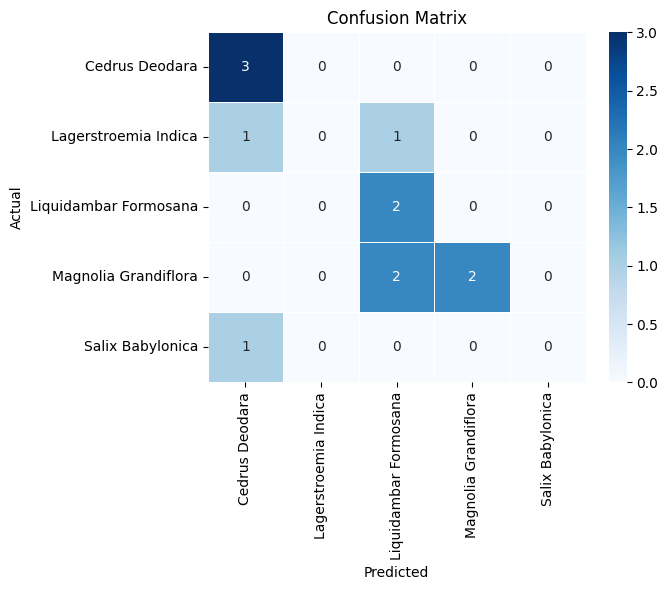

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
 
classes = ['Cedrus Deodara','Lagerstroemia Indica','Liquidambar Formosana','Magnolia Grandiflora','Salix Babylonica']
 
matrix = np.array([[3,1,0,0,1],[0,0,0,0,0],[0,1,2,2,0],[0,0,0,2,0],[0,0,0,0,0]]).T

 
plt.figure(figsize=(7, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    linewidths=0.5
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../OUTPUT/confusion_matrix_cville.png', dpi=300)
plt.show()